In [6]:
%pip install medmnist

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Define transformations
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Download and load datasets
train_dataset = PneumoniaMNIST(split='train', transform=data_transform, download=True)
val_dataset = PneumoniaMNIST(split='val', transform=data_transform, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=data_transform, download=True)

# Wrap in DataLoaders
batch_size = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 4.17M/4.17M [00:06<00:00, 623kB/s]

Training samples: 4708
Validation samples: 524
Test samples: 624


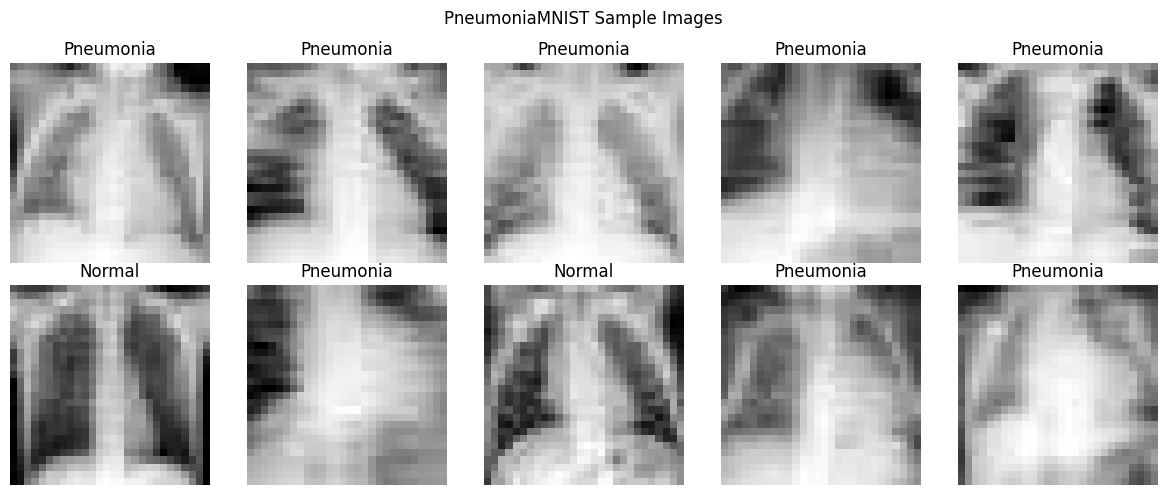

In [9]:
# Look at a few example images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title('Pneumonia' if label == 1 else 'Normal')
    ax.axis('off')
plt.suptitle('PneumoniaMNIST Sample Images')
plt.tight_layout()
plt.show()

In [10]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # First convolutional block
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Second convolutional block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Third convolutional block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PneumoniaCNN().to(device)
print(f"Using device: {device}")
print(model)

Using device: cuda
PneumoniaCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [11]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [12]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * correct / total)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {val_losses[-1]:.4f} "
          f"Val Accuracy: {val_accuracies[-1]:.2f}%")

print("Training complete!")

Epoch [1/10] Train Loss: 0.4602 Val Loss: 0.2528 Val Accuracy: 87.98%
Epoch [2/10] Train Loss: 0.2147 Val Loss: 0.1723 Val Accuracy: 92.56%
Epoch [3/10] Train Loss: 0.1600 Val Loss: 0.1241 Val Accuracy: 94.27%
Epoch [4/10] Train Loss: 0.1275 Val Loss: 0.0964 Val Accuracy: 96.18%
Epoch [5/10] Train Loss: 0.1120 Val Loss: 0.0860 Val Accuracy: 96.37%
Epoch [6/10] Train Loss: 0.1098 Val Loss: 0.0837 Val Accuracy: 96.56%
Epoch [7/10] Train Loss: 0.1104 Val Loss: 0.1157 Val Accuracy: 94.66%
Epoch [8/10] Train Loss: 0.1009 Val Loss: 0.0818 Val Accuracy: 95.80%
Epoch [9/10] Train Loss: 0.0913 Val Loss: 0.0707 Val Accuracy: 97.14%
Epoch [10/10] Train Loss: 0.0805 Val Loss: 0.0772 Val Accuracy: 96.76%
Training complete!


In [13]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.30%


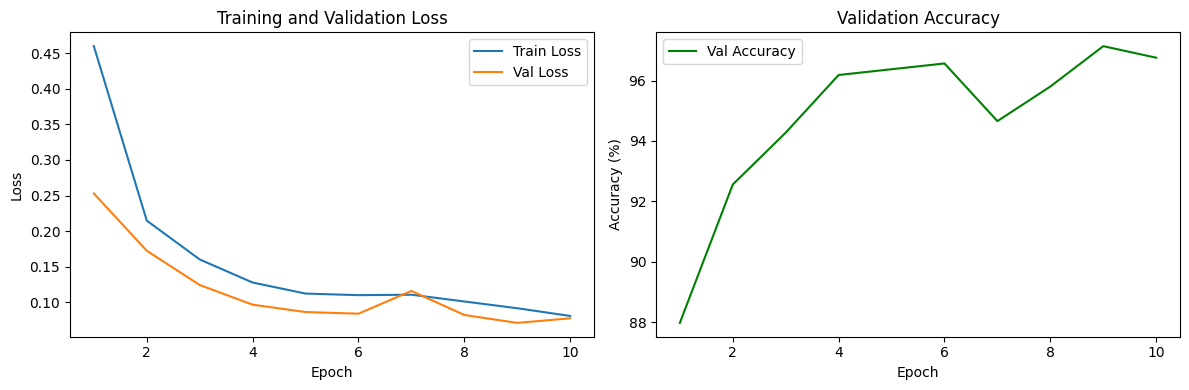

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Accuracy curve
ax2.plot(range(1, num_epochs+1), val_accuracies, label='Val Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

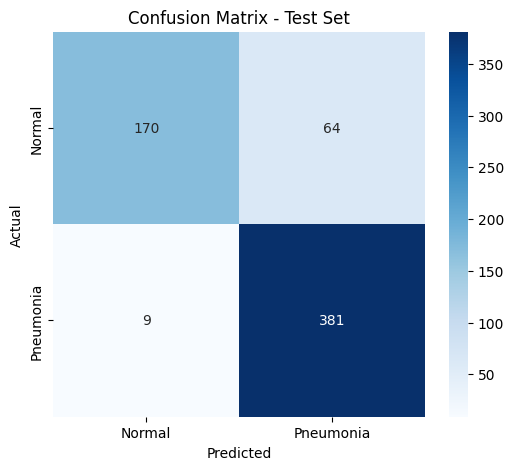

              precision    recall  f1-score   support

      Normal       0.95      0.73      0.82       234
   Pneumonia       0.86      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(classification_report(all_labels, all_preds,
                           target_names=['Normal', 'Pneumonia']))